# Purpose

Simulate GO terms that contain genes related to 1 specific cell type

In [2]:
import pandas as pd
from scipy.stats import mannwhitneyu
import anndata as ad
import scanpy as sc

In [2]:
adata = ad.read_h5ad("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessSC_pipe/data/h5ad_datasets/processed/cpm/brain_sc_with_metadata_pc_cpm.h5ad")

In [3]:
grouped_means = adata.to_df().groupby(adata.obs["Cell type"]).mean()


/tmp/ipykernel_825814/3587926268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_means = adata.to_df().groupby(adata.obs["Cell type"]).mean()


In [4]:
gene_id = "ENSG00000241973"

grouped_means.loc[:, gene_id]

Cell type
Astrocytes                         134.208466
Excitatory neurons                 286.108551
Inhibitory neurons                 175.670151
Microglial cells                   103.672165
Oligodendrocyte precursor cells     72.125977
Oligodendrocytes                   119.896118
Name: ENSG00000241973, dtype: float32

In [5]:
# Define the target cell type
target_celltype = 'Excitatory neurons'

# Identify indices
target_idx = adata.obs['Cell type'] == target_celltype
other_idx = adata.obs['Cell type'] != target_celltype

# Create a DataFrame to store p-values
results = {}



In [6]:
# Rank genes by differential expression
sc.tl.rank_genes_groups(adata, groupby='Cell type', method='wilcoxon')

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/aadrian/miniforge3/

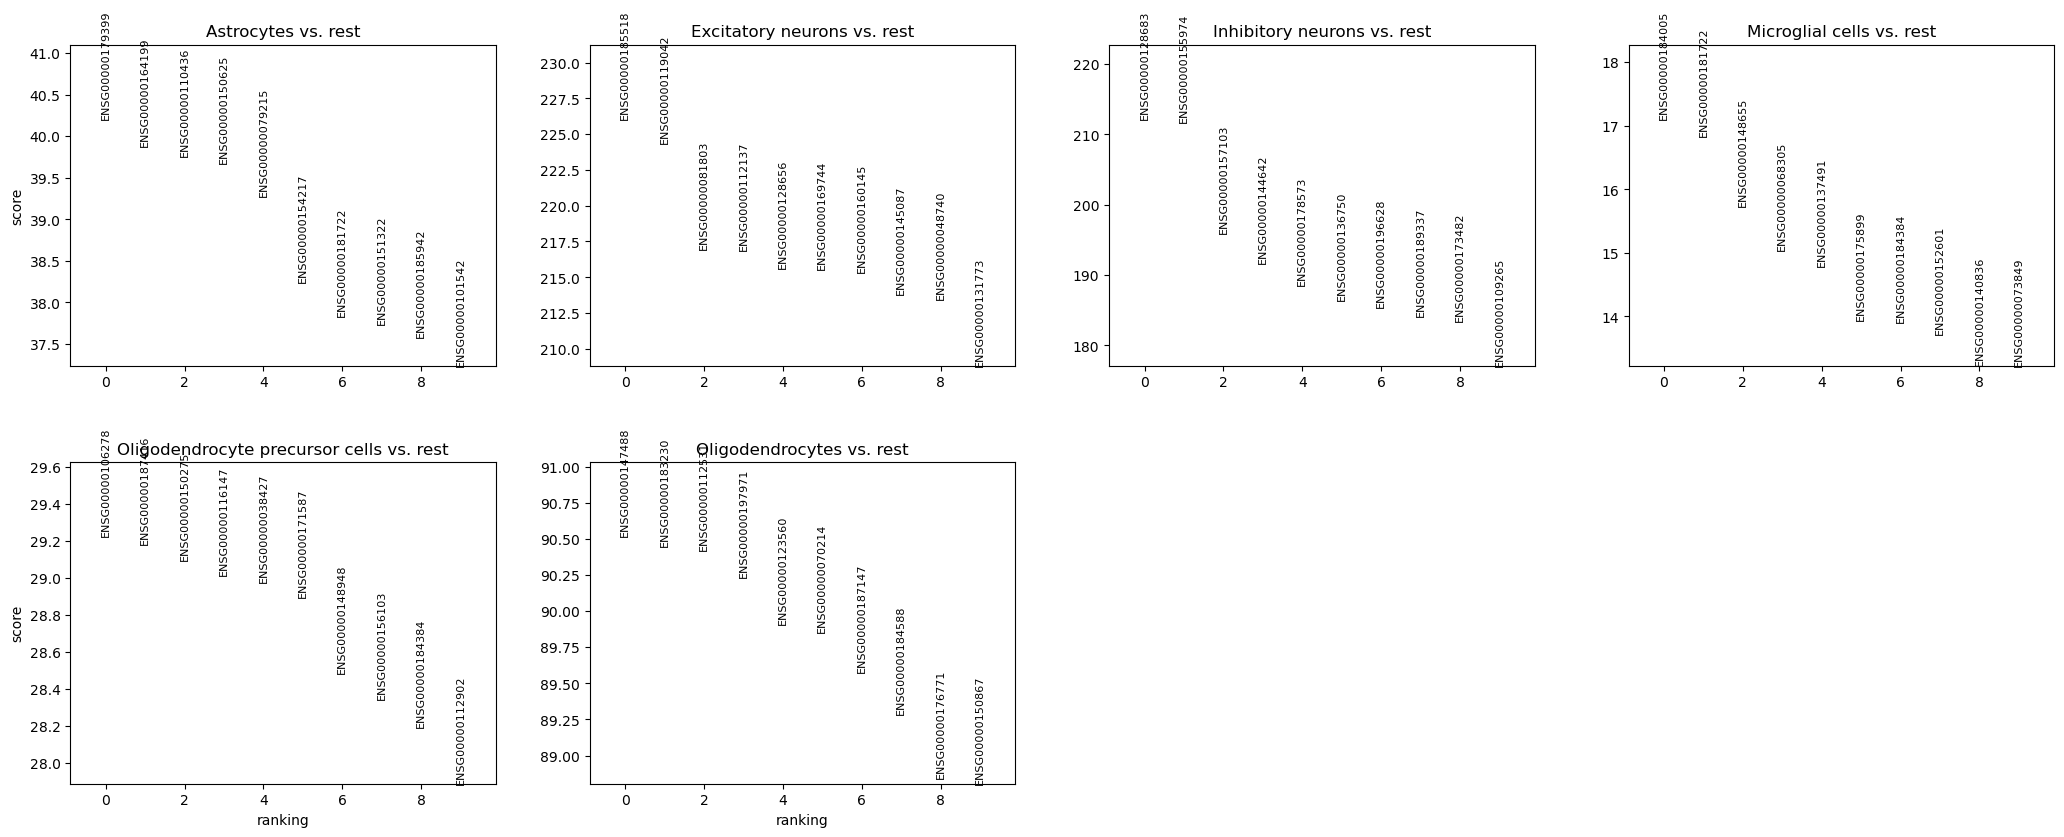

In [7]:
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)


In [8]:
# Extract data
de = adata.uns['rank_genes_groups']
ct = "Excitatory neurons"
genes = pd.Series(de['names'][ct])
scores = pd.Series(de['scores'][ct])

# Combine and sort by score (descending)
ranked = pd.DataFrame({'gene': genes, 'score': scores}).sort_values(by='score', ascending=False)

print(ranked.head(10))  # Top 10 genes by score

              gene       score
0  ENSG00000185518  226.082565
1  ENSG00000119042  224.349411
2  ENSG00000081803  216.986740
3  ENSG00000112137  216.873322
4  ENSG00000128656  215.610840
5  ENSG00000169744  215.546417
6  ENSG00000160145  215.346481
7  ENSG00000145087  213.825424
8  ENSG00000048740  213.431320
9  ENSG00000131773  208.799393


In [ ]:
def stratify(ranked):
	"""Stratify genes into 10 bins according to their ranked indexes
	"""
	# St based on 'mgc_ranked' column
	ranked = ranked.sort_values('score', ascending=False)
	n = 300
	q_top = ranked.head(n)
	q_bot = ranked.tail(n)
	q_mid = ranked.iloc[n:-n]  # excludes top and bottom 10%
	print(q_top)

	q_top["Q"]=3
	q_mid["Q"]=2
	q_bot["Q"]=1
	return [q_bot, q_mid, q_top]

def create_go_term(i, df):
	"""Create 1 GO term by sampling genes from df

	Args:
		i (int): stratification level we are sampling from
		df (_type_): colntains genes from strat level
	"""
	go = df.sample(30) # number of genes contained in new go term
	go['GOID'] = f"SIMGO_{i}"
	go = go.loc[:,['gene','GOID', 'score']]
	return go

def simulate_quartile_go_terms(q_df):
	lo_go_terms = []

	for i  in range(1,1000): # how many GO terms we want to simulate
		go_term = create_go_term(i, q_df)
		lo_go_terms.append(go_term)
	return pd.concat(lo_go_terms, axis = 0)
	
def sim(lo_dfs):
	"""simulate GO terms that only contain genes of a specific subset of ranked indexes

	Args:
		lo_dfs (List): List of dfs where each df contains genes we want to sample from to create a GO term

	Returns:
		pd.DataFrame: contains simulatded GO terms and gene membership
	"""
	lo_qs = []
	for i, q_df in enumerate(lo_dfs):
		
		df = simulate_quartile_go_terms(q_df)
		df['GO.ID'] = df['GOID'].astype(str) + "_Q" +str(i+1)
		df['Q']=i+1
		lo_qs.append(df)
	df = pd.concat(lo_qs, axis = 0)
	df.reset_index(drop=True, inplace=True)
	df.rename(columns={'gene':'ensembl_gene_id'}, inplace=True)
	return df


In [ ]:
def __main__(path_to_rankeds, save_path):
	ranked = pd.read_csv(path_to_rankeds, index_col=0)
	# stratify genes
	lo_dfs = stratify(ranked)
	# sim go terms
	sims = sim(lo_dfs=lo_dfs)
	# save
	sims.to_csv(save_path, index=None)
	return sims

sims = __main__('data/excitatory_neuron_de.csv', 'data/excitatory_neuron_GOs.csv')

                gene       score
0    ENSG00000185518  226.082570
1    ENSG00000119042  224.349410
2    ENSG00000081803  216.986740
3    ENSG00000112137  216.873320
4    ENSG00000128656  215.610840
..               ...         ...
295  ENSG00000123416  107.209206
296  ENSG00000034510  107.193640
297  ENSG00000145982  106.765260
298  ENSG00000189181  106.738540
299  ENSG00000241973  106.653534

[300 rows x 2 columns]


/tmp/ipykernel_1169270/3548653193.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q_top["Q"]=3
/tmp/ipykernel_1169270/3548653193.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q_mid["Q"]=2
/tmp/ipykernel_1169270/3548653193.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vi

# Plot DE Gene content in groups

/tmp/ipykernel_3621614/3099102595.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(),


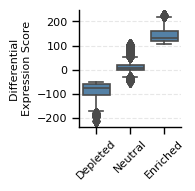

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot(figsize=(8, 8), label_size=14, title_size=16, tick_size=12, dpi=300):
    """
    Create a boxplot with customizable size and label parameters.
    
    Parameters:
    -----------
    figsize : tuple, default=(8, 8)
        Figure size as (width, height) in inches
    label_size : int, default=14
        Font size for axis labels
    title_size : int, default=16
        Font size for plot title
    tick_size : int, default=12
        Font size for tick labels
    dpi : int, default=300
        Resolution for saved figures
    """
    # Read data
    sims = pd.read_csv("../data/excitatory_neuron_GOs.csv")
    
    # Set aesthetic parameters
    sns.set_context("paper")  # Increased base font scale
    
    # Create the plot with customizable figure size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot
    sns.boxplot(data=sims, y='score', x='Q', color='steelblue', ax=ax)
    
    # Add title with larger font
    # ax.set_title("Gene Excitatory Neuron Relatedness in Function", 
                #  fontsize=title_size, fontweight='bold', pad=20)
    
    # Set x-tick labels with custom size
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Depleted', 'Neutral', 'Enriched'], 
                       fontsize=tick_size, rotation=45)
    ax.set_yticklabels(ax.get_yticklabels(), 
                    fontsize=tick_size)
    
    # Set axis labels with larger font
    ax.set_xlabel("")
    # ax.set_xlabel("Function Type", 
                #   fontsize=lab/el_size, fontweight='semibold')
    ax.set_ylabel("Differential \nExpression Score", 
                  fontsize=label_size)
    
    # Adjust y-tick label size
    ax.tick_params(axis='y', labelsize=tick_size)
    
    # Optional: Add grid for better readability
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)
    
    # Despine and clean up
    sns.despine()
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save figures with customizable DPI
    plt.savefig("results/exi_function_dist.png", dpi=dpi, bbox_inches='tight')
    plt.savefig("results/exi_function_dist.pdf")
    
    # plt.show()


# Smaller plot for publication
plot(figsize=(2, 2), label_size=8, title_size=4, tick_size=8)


In [16]:
# sims = pd.read_csv("data/excitatory_neuron_GOs.csv")
import os
os.getcwd()


'/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/analysis/PaperFigs/SimulatedBulk/sim_functions_sim_data/final'